### BYTE PAIR ENCODING by Andrej Karpathy


**BPE Tokenizer**

unicode

In [ ]:
ord("안")

50504

In [ ]:
[ord(x) for x in "안녕하세요 (hello in Korean!)"]


[50504,
 45397,
 54616,
 49464,
 50836,
 32,
 40,
 104,
 101,
 108,
 108,
 111,
 32,
 105,
 110,
 32,
 75,
 111,
 114,
 101,
 97,
 110,
 33,
 41]

In [ ]:
len(list("hello in Korean"))

15

In [ ]:
list("hello in Korean".encode("UTF-8"))

[104, 101, 108, 108, 111, 32, 105, 110, 32, 75, 111, 114, 101, 97, 110]

In [ ]:
len(list("안녕하세요"))

5

In [ ]:
len(list("안녕하세요".encode("UTF-8")))

15

In [ ]:
len(list("안녕하세요 (hello in Korean!)".encode("UTF-8")))

34

In [ ]:
"안녕하세요 (hello in Korean!)".encode("UTF-8")

b'\xec\x95\x88\xeb\x85\x95\xed\x95\x98\xec\x84\xb8\xec\x9a\x94 (hello in Korean!)'

In [ ]:
# text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = "Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception."
tokens=text.encode("UTF-8")
print(len(text))
print(tokens)

tokens=list(map(int,tokens))
print(tokens)
print(len(tokens))

533
b'\xef\xbc\xb5\xef\xbd\x8e\xef\xbd\x89\xef\xbd\x83\xef\xbd\x8f\xef\xbd\x84\xef\xbd\x85! \xf0\x9f\x85\xa4\xf0\x9f\x85\x9d\xf0\x9f\x85\x98\xf0\x9f\x85\x92\xf0\x9f\x85\x9e\xf0\x9f\x85\x93\xf0\x9f\x85\x94\xe2\x80\xbd \xf0\x9f\x87\xba\xe2\x80\x8c\xf0\x9f\x87\xb3\xe2\x80\x8c\xf0\x9f\x87\xae\xe2\x80\x8c\xf0\x9f\x87\xa8\xe2\x80\x8c\xf0\x9f\x87\xb4\xe2\x80\x8c\xf0\x9f\x87\xa9\xe2\x80\x8c\xf0\x9f\x87\xaa! \xf0\x9f\x98\x84 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to \xe2\x80\x9csupport Unicode\xe2\x80\x9d in our software (whatever that means\xe2\x80\x94like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don\xe2\x80\x99t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode\xe2\x80\x99s inception.'
[239, 188, 181, 239, 189,

In [ ]:
def get_stats(ids):
  counts={}
  for pair in zip(ids,ids[1:]):
    #dictionary.get(key, default_value)
    counts[pair]=counts.get(pair,0)+1
  return counts
stats=get_stats(tokens)
#print(stats)
print(sorted(((v,k) for k,v in stats.items()), reverse=True))

[(20, (101, 32)), (15, (240, 159)), (12, (226, 128)), (12, (105, 110)), (10, (115, 32)), (10, (97, 110)), (10, (32, 97)), (9, (32, 116)), (8, (116, 104)), (7, (159, 135)), (7, (159, 133)), (7, (97, 114)), (6, (239, 189)), (6, (140, 240)), (6, (128, 140)), (6, (116, 32)), (6, (114, 32)), (6, (111, 114)), (6, (110, 103)), (6, (110, 100)), (6, (109, 101)), (6, (104, 101)), (6, (101, 114)), (6, (32, 105)), (5, (117, 115)), (5, (115, 116)), (5, (110, 32)), (5, (100, 101)), (5, (44, 32)), (5, (32, 115)), (4, (116, 105)), (4, (116, 101)), (4, (115, 44)), (4, (114, 105)), (4, (111, 117)), (4, (111, 100)), (4, (110, 116)), (4, (110, 105)), (4, (105, 99)), (4, (104, 97)), (4, (103, 32)), (4, (101, 97)), (4, (100, 32)), (4, (99, 111)), (4, (97, 109)), (4, (85, 110)), (4, (32, 119)), (4, (32, 111)), (4, (32, 102)), (4, (32, 85)), (3, (118, 101)), (3, (116, 115)), (3, (116, 114)), (3, (116, 111)), (3, (114, 116)), (3, (114, 115)), (3, (114, 101)), (3, (111, 102)), (3, (111, 32)), (3, (108, 108)), (

In [ ]:
top_pair=max(stats,key=stats.get)
top_pair

(101, 32)

In [ ]:
chr(101) , chr(32)

('e', ' ')

In [ ]:
def merge(ids,pair,idx):
  newids=[]
  i=0
  while i< len(ids):

    if i<len(ids) -1 and ids[i]==pair[0] and ids[i+1]==pair[1]:
      newids.append(idx)
      i+=2
    else:
      newids.append(ids[i])
      i+=1
  return newids

print(merge([1,2,3,4,5,6,7],(5,6),256))


[1, 2, 3, 4, 256, 7]


In [ ]:
new_token=merge(tokens,top_pair,256)
len(new_token) ,len(tokens)

(596, 616)

In [ ]:
after_replace=sorted(merge(tokens,top_pair,256),reverse=True)
count=0
for i in after_replace:
  if i==256:
    count+=1
print(count)

20


In [ ]:
# making the training text longer to have more representative token statistics
# text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = """A Programmer’s Introduction to Unicode March 3, 2017 · Coding · 22 Comments  Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺\u200c🇳\u200c🇮\u200c🇨\u200c🇴\u200c🇩\u200c🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.  A few months ago, I got interested in Unicode and decided to spend some time learning more about it in detail. In this article, I’ll give an introduction to it from a programmer’s point of view.  I’m going to focus on the character set and what’s involved in working with strings and files of Unicode text. However, in this article I’m not going to talk about fonts, text layout/shaping/rendering, or localization in detail—those are separate issues, beyond my scope (and knowledge) here.  Diversity and Inherent Complexity The Unicode Codespace Codespace Allocation Scripts Usage Frequency Encodings UTF-8 UTF-16 Combining Marks Canonical Equivalence Normalization Forms Grapheme Clusters And More… Diversity and Inherent Complexity As soon as you start to study Unicode, it becomes clear that it represents a large jump in complexity over character sets like ASCII that you may be more familiar with. It’s not just that Unicode contains a much larger number of characters, although that’s part of it. Unicode also has a great deal of internal structure, features, and special cases, making it much more than what one might expect a mere “character set” to be. We’ll see some of that later in this article.  When confronting all this complexity, especially as an engineer, it’s hard not to find oneself asking, “Why do we need all this? Is this really necessary? Couldn’t it be simplified?”  However, Unicode aims to faithfully represent the entire world’s writing systems. The Unicode Consortium’s stated goal is “enabling people around the world to use computers in any language”. And as you might imagine, the diversity of written languages is immense! To date, Unicode supports 135 different scripts, covering some 1100 languages, and there’s still a long tail of over 100 unsupported scripts, both modern and historical, which people are still working to add.  Given this enormous diversity, it’s inevitable that representing it is a complicated project. Unicode embraces that diversity, and accepts the complexity inherent in its mission to include all human writing systems. It doesn’t make a lot of trade-offs in the name of simplification, and it makes exceptions to its own rules where necessary to further its mission.  Moreover, Unicode is committed not just to supporting texts in any single language, but also to letting multiple languages coexist within one text—which introduces even more complexity.  Most programming languages have libraries available to handle the gory low-level details of text manipulation, but as a programmer, you’ll still need to know about certain Unicode features in order to know when and how to apply them. It may take some time to wrap your head around it all, but don’t be discouraged—think about the billions of people for whom your software will be more accessible through supporting text in their language. Embrace the complexity!  The Unicode Codespace Let’s start with some general orientation. The basic elements of Unicode—its “characters”, although that term isn’t quite right—are called code points. Code points are identified by number, customarily written in hexadecimal with the prefix “U+”, such as U+0041 “A” latin capital letter a or U+03B8 “θ” greek small letter theta. Each code point also has a short name, and quite a few other properties, specified in the Unicode Character Database.  The set of all possible code points is called the codespace. The Unicode codespace consists of 1,114,112 code points. However, only 128,237 of them—about 12% of the codespace—are actually assigned, to date. There’s plenty of room for growth! Unicode also reserves an additional 137,468 code points as “private use” areas, which have no standardized meaning and are available for individual applications to define for their own purposes.  Codespace Allocation To get a feel for how the codespace is laid out, it’s helpful to visualize it. Below is a map of the entire codespace, with one pixel per code point. It’s arranged in tiles for visual coherence; each small square is 16×16 = 256 code points, and each large square is a “plane” of 65,536 code points. There are 17 planes altogether.  Map of the Unicode codespace (click to zoom)  White represents unassigned space. Blue is assigned code points, green is private-use areas, and the small red area is surrogates (more about those later). As you can see, the assigned code points are distributed somewhat sparsely, but concentrated in the first three planes.  Plane 0 is also known as the “Basic Multilingual Plane”, or BMP. The BMP contains essentially all the characters needed for modern text in any script, including Latin, Cyrillic, Greek, Han (Chinese), Japanese, Korean, Arabic, Hebrew, Devanagari (Indian), and many more.  (In the past, the codespace was just the BMP and no more—Unicode was originally conceived as a straightforward 16-bit encoding, with only 65,536 code points. It was expanded to its current size in 1996. However, the vast majority of code points in modern text belong to the BMP.)  Plane 1 contains historical scripts, such as Sumerian cuneiform and Egyptian hieroglyphs, as well as emoji and various other symbols. Plane 2 contains a large block of less-common and historical Han characters. The remaining planes are empty, except for a small number of rarely-used formatting characters in Plane 14; planes 15–16 are reserved entirely for private use.  Scripts Let’s zoom in on the first three planes, since that’s where the action is:  Map of scripts in Unicode planes 0–2 (click to zoom)  This map color-codes the 135 different scripts in Unicode. You can see how Han () and Korean () take up most of the range of the BMP (the left large square). By contrast, all of the European, Middle Eastern, and South Asian scripts fit into the first row of the BMP in this diagram.  Many areas of the codespace are adapted or copied from earlier encodings. For example, the first 128 code points of Unicode are just a copy of ASCII. This has clear benefits for compatibility—it’s easy to losslessly convert texts from smaller encodings into Unicode (and the other direction too, as long as no characters outside the smaller encoding are used).  Usage Frequency One more interesting way to visualize the codespace is to look at the distribution of usage—in other words, how often each code point is actually used in real-world texts. Below is a heat map of planes 0–2 based on a large sample of text from Wikipedia and Twitter (all languages). Frequency increases from black (never seen) through red and yellow to white.  Heat map of code point usage frequency in Unicode planes 0–2 (click to zoom)  You can see that the vast majority of this text sample lies in the BMP, with only scattered usage of code points from planes 1–2. The biggest exception is emoji, which show up here as the several bright squares in the bottom row of plane 1.  Encodings We’ve seen that Unicode code points are abstractly identified by their index in the codespace, ranging from U+0000 to U+10FFFF. But how do code points get represented as bytes, in memory or in a file?  The most convenient, computer-friendliest (and programmer-friendliest) thing to do would be to just store the code point index as a 32-bit integer. This works, but it consumes 4 bytes per code point, which is sort of a lot. Using 32-bit ints for Unicode will cost you a bunch of extra storage, memory, and performance in bandwidth-bound scenarios, if you work with a lot of text.  Consequently, there are several more-compact encodings for Unicode. The 32-bit integer encoding is officially called UTF-32 (UTF = “Unicode Transformation Format”), but it’s rarely used for storage. At most, it comes up sometimes as a temporary internal representation, for examining or operating on the code points in a string.  Much more commonly, you’ll see Unicode text encoded as either UTF-8 or UTF-16. These are both variable-length encodings, made up of 8-bit or 16-bit units, respectively. In these schemes, code points with smaller index values take up fewer bytes, which saves a lot of memory for typical texts. The trade-off is that processing UTF-8/16 texts is more programmatically involved, and likely slower.  UTF-8 In UTF-8, each code point is stored using 1 to 4 bytes, based on its index value.  UTF-8 uses a system of binary prefixes, in which the high bits of each byte mark whether it’s a single byte, the beginning of a multi-byte sequence, or a continuation byte; the remaining bits, concatenated, give the code point index. This table shows how it works:  UTF-8 (binary)\tCode point (binary)\tRange 0xxxxxxx\txxxxxxx\tU+0000–U+007F 110xxxxx 10yyyyyy\txxxxxyyyyyy\tU+0080–U+07FF 1110xxxx 10yyyyyy 10zzzzzz\txxxxyyyyyyzzzzzz\tU+0800–U+FFFF 11110xxx 10yyyyyy 10zzzzzz 10wwwwww\txxxyyyyyyzzzzzzwwwwww\tU+10000–U+10FFFF A handy property of UTF-8 is that code points below 128 (ASCII characters) are encoded as single bytes, and all non-ASCII code points are encoded using sequences of bytes 128–255. This has a couple of nice consequences. First, any strings or files out there that are already in ASCII can also be interpreted as UTF-8 without any conversion. Second, lots of widely-used string programming idioms—such as null termination, or delimiters (newlines, tabs, commas, slashes, etc.)—will just work on UTF-8 strings. ASCII bytes never occur inside the encoding of non-ASCII code points, so searching byte-wise for a null terminator or a delimiter will do the right thing.  Thanks to this convenience, it’s relatively simple to extend legacy ASCII programs and APIs to handle UTF-8 strings. UTF-8 is very widely used in the Unix/Linux and Web worlds, and many programmers argue UTF-8 should be the default encoding everywhere.  However, UTF-8 isn’t a drop-in replacement for ASCII strings in all respects. For instance, code that iterates over the “characters” in a string will need to decode UTF-8 and iterate over code points (or maybe grapheme clusters—more about those later), not bytes. When you measure the “length” of a string, you’ll need to think about whether you want the length in bytes, the length in code points, the width of the text when rendered, or something else.  UTF-16 The other encoding that you’re likely to encounter is UTF-16. It uses 16-bit words, with each code point stored as either 1 or 2 words.  Like UTF-8, we can express the UTF-16 encoding rules in the form of binary prefixes:  UTF-16 (binary)\tCode point (binary)\tRange xxxxxxxxxxxxxxxx\txxxxxxxxxxxxxxxx\tU+0000–U+FFFF 110110xxxxxxxxxx 110111yyyyyyyyyy\txxxxxxxxxxyyyyyyyyyy + 0x10000\tU+10000–U+10FFFF A more common way that people talk about UTF-16 encoding, though, is in terms of code points called “surrogates”. All the code points in the range U+D800–U+DFFF—or in other words, the code points that match the binary prefixes 110110 and 110111 in the table above—are reserved specifically for UTF-16 encoding, and don’t represent any valid characters on their own. They’re only meant to occur in the 2-word encoding pattern above, which is called a “surrogate pair”. Surrogate code points are illegal in any other context! They’re not allowed in UTF-8 or UTF-32 at all.  Historically, UTF-16 is a descendant of the original, pre-1996 versions of Unicode, in which there were only 65,536 code points. The original intention was that there would be no different “encodings”; Unicode was supposed to be a straightforward 16-bit character set. Later, the codespace was expanded to make room for a long tail of less-common (but still important) Han characters, which the Unicode designers didn’t originally plan for. Surrogates were then introduced, as—to put it bluntly—a kludge, allowing 16-bit encodings to access the new code points.  Today, Javascript uses UTF-16 as its standard string representation: if you ask for the length of a string, or iterate over it, etc., the result will be in UTF-16 words, with any code points outside the BMP expressed as surrogate pairs. UTF-16 is also used by the Microsoft Win32 APIs; though Win32 supports either 8-bit or 16-bit strings, the 8-bit version unaccountably still doesn’t support UTF-8—only legacy code-page encodings, like ANSI. This leaves UTF-16 as the only way to get proper Unicode support in Windows. (Update: in Win10 version 1903, they finally added UTF-8 support to the 8-bit APIs! 😊)  By the way, UTF-16’s words can be stored either little-endian or big-endian. Unicode has no opinion on that issue, though it does encourage the convention of putting U+FEFF zero width no-break space at the top of a UTF-16 file as a byte-order mark, to disambiguate the endianness. (If the file doesn’t match the system’s endianness, the BOM will be decoded as U+FFFE, which isn’t a valid code point.)  Combining Marks In the story so far, we’ve been focusing on code points. But in Unicode, a “character” can be more complicated than just an individual code point!  Unicode includes a system for dynamically composing characters, by combining multiple code points together. This is used in various ways to gain flexibility without causing a huge combinatorial explosion in the number of code points.  In European languages, for example, this shows up in the application of diacritics to letters. Unicode supports a wide range of diacritics, including acute and grave accents, umlauts, cedillas, and many more. All these diacritics can be applied to any letter of any alphabet—and in fact, multiple diacritics can be used on a single letter.  If Unicode tried to assign a distinct code point to every possible combination of letter and diacritics, things would rapidly get out of hand. Instead, the dynamic composition system enables you to construct the character you want, by starting with a base code point (the letter) and appending additional code points, called “combining marks”, to specify the diacritics. When a text renderer sees a sequence like this in a string, it automatically stacks the diacritics over or under the base letter to create a composed character.  For example, the accented character “Á” can be expressed as a string of two code points: U+0041 “A” latin capital letter a plus U+0301 “◌́” combining acute accent. This string automatically gets rendered as a single character: “Á”.  Now, Unicode does also include many “precomposed” code points, each representing a letter with some combination of diacritics already applied, such as U+00C1 “Á” latin capital letter a with acute or U+1EC7 “ệ” latin small letter e with circumflex and dot below. I suspect these are mostly inherited from older encodings that were assimilated into Unicode, and kept around for compatibility. In practice, there are precomposed code points for most of the common letter-with-diacritic combinations in European-script languages, so they don’t use dynamic composition that much in typical text.  Still, the system of combining marks does allow for an arbitrary number of diacritics to be stacked on any base character. The reductio-ad-absurdum of this is Zalgo text, which works by ͖͟ͅr͞aṋ̫̠̖͈̗d͖̻̹óm̪͙͕̗̝ļ͇̰͓̳̫ý͓̥̟͍ ̕s̫t̫̱͕̗̰̼̘͜a̼̩͖͇̠͈̣͝c̙͍k̖̱̹͍͘i̢n̨̺̝͇͇̟͙ģ̫̮͎̻̟ͅ ̕n̼̺͈͞u̮͙m̺̭̟̗͞e̞͓̰̤͓̫r̵o̖ṷs҉̪͍̭̬̝̤ ̮͉̝̞̗̟͠d̴̟̜̱͕͚i͇̫̼̯̭̜͡ḁ͙̻̼c̲̲̹r̨̠̹̣̰̦i̱t̤̻̤͍͙̘̕i̵̜̭̤̱͎c̵s ͘o̱̲͈̙͖͇̲͢n͘ ̜͈e̬̲̠̩ac͕̺̠͉h̷̪ ̺̣͖̱ḻ̫̬̝̹ḙ̙̺͙̭͓̲t̞̞͇̲͉͍t̷͔̪͉̲̻̠͙e̦̻͈͉͇r͇̭̭̬͖,̖́ ̜͙͓̣̭s̘̘͈o̱̰̤̲ͅ ̛̬̜̙t̼̦͕̱̹͕̥h̳̲͈͝ͅa̦t̻̲ ̻̟̭̦̖t̛̰̩h̠͕̳̝̫͕e͈̤̘͖̞͘y҉̝͙ ̷͉͔̰̠o̞̰v͈͈̳̘͜er̶f̰͈͔ḻ͕̘̫̺̲o̲̭͙͠ͅw̱̳̺ ͜t̸h͇̭͕̳͍e̖̯̟̠ ͍̞̜͔̩̪͜ļ͎̪̲͚i̝̲̹̙̩̹n̨̦̩̖ḙ̼̲̼͢ͅ ̬͝s̼͚̘̞͝p͙̘̻a̙c҉͉̜̤͈̯̖i̥͡n̦̠̱͟g̸̗̻̦̭̮̟ͅ ̳̪̠͖̳̯̕a̫͜n͝d͡ ̣̦̙ͅc̪̗r̴͙̮̦̹̳e͇͚̞͔̹̫͟a̙̺̙ț͔͎̘̹ͅe̥̩͍ a͖̪̜̮͙̹n̢͉̝ ͇͉͓̦̼́a̳͖̪̤̱p̖͔͔̟͇͎͠p̱͍̺ę̲͎͈̰̲̤̫a̯͜r̨̮̫̣̘a̩̯͖n̹̦̰͎̣̞̞c̨̦̱͔͎͍͖e̬͓͘ ̤̰̩͙̤̬͙o̵̼̻̬̻͇̮̪f̴ ̡̙̭͓͖̪̤“̸͙̠̼c̳̗͜o͏̼͙͔̮r̞̫̺̞̥̬ru̺̻̯͉̭̻̯p̰̥͓̣̫̙̤͢t̳͍̳̖ͅi̶͈̝͙̼̙̹o̡͔n̙̺̹̖̩͝ͅ”̨̗͖͚̩.̯͓  A few other places where dynamic character composition shows up in Unicode:  Vowel-pointing notation in Arabic and Hebrew. In these languages, words are normally spelled with some of their vowels left out. They then have diacritic notation to indicate the vowels (used in dictionaries, language-teaching materials, children’s books, and such). These diacritics are expressed with combining marks.  A Hebrew example, with niqqud:\tאֶת דַלְתִּי הֵזִיז הֵנִיעַ, קֶטֶב לִשְׁכַּתִּי יָשׁוֹד Normal writing (no niqqud):\tאת דלתי הזיז הניע, קטב לשכתי ישוד Devanagari, the script used to write Hindi, Sanskrit, and many other South Asian languages, expresses certain vowels as combining marks attached to consonant letters. For example, “ह” + “\u200bि” = “हि” (“h” + “i” = “hi”). Korean characters stand for syllables, but they are composed of letters called jamo that stand for the vowels and consonants in the syllable. While there are code points for precomposed Korean syllables, it’s also possible to dynamically compose them by concatenating their jamo. For example, “ᄒ” + “ᅡ” + “ᆫ” = “한” (“h” + “a” + “n” = “han”). Canonical Equivalence In Unicode, precomposed characters exist alongside the dynamic composition system. A consequence of this is that there are multiple ways to express “the same” string—different sequences of code points that result in the same user-perceived characters. For example, as we saw earlier, we can express the character “Á” either as the single code point U+00C1, or as the string of two code points U+0041 U+0301.  Another source of ambiguity is the ordering of multiple diacritics in a single character. Diacritic order matters visually when two diacritics apply to the same side of the base character, e.g. both above: “ǡ” (dot, then macron) is different from “ā̇” (macron, then dot). However, when diacritics apply to different sides of the character, e.g. one above and one below, then the order doesn’t affect rendering. Moreover, a character with multiple diacritics might have one of the diacritics precomposed and others expressed as combining marks.  For example, the Vietnamese letter “ệ” can be expressed in five different ways:  Fully precomposed: U+1EC7 “ệ” Partially precomposed: U+1EB9 “ẹ” + U+0302 “◌̂” Partially precomposed: U+00EA “ê” + U+0323 “◌̣” Fully decomposed: U+0065 “e” + U+0323 “◌̣” + U+0302 “◌̂” Fully decomposed: U+0065 “e” + U+0302 “◌̂” + U+0323 “◌̣” Unicode refers to set of strings like this as “canonically equivalent”. Canonically equivalent strings are supposed to be treated as identical for purposes of searching, sorting, rendering, text selection, and so on. This has implications for how you implement operations on text. For example, if an app has a “find in file” operation and the user searches for “ệ”, it should, by default, find occurrences of any of the five versions of “ệ” above!  Normalization Forms To address the problem of “how to handle canonically equivalent strings”, Unicode defines several normalization forms: ways of converting strings into a canonical form so that they can be compared code-point-by-code-point (or byte-by-byte).  The “NFD” normalization form fully decomposes every character down to its component base and combining marks, taking apart any precomposed code points in the string. It also sorts the combining marks in each character according to their rendered position, so e.g. diacritics that go below the character come before the ones that go above the character. (It doesn’t reorder diacritics in the same rendered position, since their order matters visually, as previously mentioned.)  The “NFC” form, conversely, puts things back together into precomposed code points as much as possible. If an unusual combination of diacritics is called for, there may not be any precomposed code point for it, in which case NFC still precomposes what it can and leaves any remaining combining marks in place (again ordered by rendered position, as in NFD).  There are also forms called NFKD and NFKC. The “K” here refers to compatibility decompositions, which cover characters that are “similar” in some sense but not visually identical. However, I’m not going to cover that here.  Grapheme Clusters As we’ve seen, Unicode contains various cases where a thing that a user thinks of as a single “character” might actually be made up of multiple code points under the hood. Unicode formalizes this using the notion of a grapheme cluster: a string of one or more code points that constitute a single “user-perceived character”.  UAX #29 defines the rules for what, precisely, qualifies as a grapheme cluster. It’s approximately “a base code point followed by any number of combining marks”, but the actual definition is a bit more complicated; it accounts for things like Korean jamo, and emoji ZWJ sequences.  The main thing grapheme clusters are used for is text editing: they’re often the most sensible unit for cursor placement and text selection boundaries. Using grapheme clusters for these purposes ensures that you can’t accidentally chop off some diacritics when you copy-and-paste text, that left/right arrow keys always move the cursor by one visible character, and so on.  Another place where grapheme clusters are useful is in enforcing a string length limit—say, on a database field. While the true, underlying limit might be something like the byte length of the string in UTF-8, you wouldn’t want to enforce that by just truncating bytes. At a minimum, you’d want to “round down” to the nearest code point boundary; but even better, round down to the nearest grapheme cluster boundary. Otherwise, you might be corrupting the last character by cutting off a diacritic, or interrupting a jamo sequence or ZWJ sequence.  And More… There’s much more that could be said about Unicode from a programmer’s perspective! I haven’t gotten into such fun topics as case mapping, collation, compatibility decompositions and confusables, Unicode-aware regexes, or bidirectional text. Nor have I said anything yet about implementation issues—how to efficiently store and look-up data about the sparsely-assigned code points, or how to optimize UTF-8 decoding, string comparison, or NFC normalization. Perhaps I’ll return to some of those things in future posts.  Unicode is a fascinating and complex system. It has a many-to-one mapping between bytes and code points, and on top of that a many-to-one (or, under some circumstances, many-to-many) mapping between code points and “characters”. It has oddball special cases in every corner. But no one ever claimed that representing all written languages was going to be easy, and it’s clear that we’re never going back to the bad old days of a patchwork of incompatible encodings.  Further reading:  The Unicode Standard UTF-8 Everywhere Manifesto Dark corners of Unicode by Eevee ICU (International Components for Unicode)—C/C++/Java libraries implementing many Unicode algorithms and related things Python 3 Unicode Howto Google Noto Fonts—set of fonts intended to cover all assigned code points"""
tokens=text.encode('UTF-8')
tokens=list(map(int,tokens))



`  get_stats `
دي بتحسب عدد مرات ظهور كل زوج متجاور.


In [ ]:

def get_stats(ids):
  counts={}
  for pair in zip(ids,ids[1:]):
    counts[pair]=counts.get(pair,0)+1
  return counts

#------------------------------------------
def merge(ids,pair,idx):
  newids=[]
  i=0
  while i <len(ids) :
    if i < len(ids) -1 and  ids[i] == pair[0] and ids[i+1]==pair[1]:
      newids.append(idx)
      i+=2
    else:
      newids.append(ids[i])
      i+=1
  return newids
#------------------------------------------
vocab_size=400
num_merges=vocab_size-256
merges={}
for  i in range(num_merges):
  stats=get_stats(tokens)
  pair=max(stats,key=stats.get)
  idx=256+i
  tokens=merge(tokens,pair,idx)
  merges[pair]=idx
print(merges)
print(len(merges))
#_-----------------------------------------
vocab={}
for idx in range (256):
  vocab[idx]=bytes([idx])
print(vocab)

for (p0,p1),idx in merges.items():
    vocab[idx]= vocab[p0]+vocab[p1]
print(vocab)



{(101, 32): 256, (105, 110): 257, (115, 32): 258, (116, 104): 259, (101, 114): 260, (99, 111): 261, (116, 32): 262, (226, 128): 263, (44, 32): 264, (97, 110): 265, (111, 114): 266, (100, 32): 267, (97, 114): 268, (101, 110): 269, (257, 103): 270, (261, 100): 271, (121, 32): 272, (46, 32): 273, (97, 108): 274, (259, 256): 275, (111, 110): 276, (111, 32): 277, (116, 105): 278, (97, 99): 279, (101, 115): 280, (111, 102): 281, (271, 256): 282, (112, 111): 283, (270, 32): 284, (281, 32): 285, (101, 267): 286, (116, 260): 287, (116, 277): 288, (257, 32): 289, (97, 32): 290, (266, 32): 291, (115, 116): 292, (111, 117): 293, (99, 104): 294, (120, 120): 295, (101, 120): 296, (101, 258): 297, (263, 156): 298, (263, 157): 299, (261, 109): 300, (265, 267): 301, (112, 108): 302, (105, 116): 303, (283, 257): 304, (114, 101): 305, (263, 153): 306, (110, 105): 307, (274, 108): 308, (97, 116): 309, (260, 32): 310, (105, 258): 311, (282, 304): 312, (97, 258): 313, (85, 307): 314, (278, 276): 315, (100, 

In [ ]:
print("token lenght:",len(tokens))
print("ids lenght:",len(ids))
print(f"compression ratio: {len(tokens) / len(ids):.2f}x")

token lenght: 13186
ids lenght: 21
compression ratio: 627.90x


Note, the Tokenizer is a completely separate, independent module from the LLM. It has its own training dataset of text (which could be different from that of the LLM), on which you train the vocabulary using the Byte Pair Encoding (BPE) algorithm. It then translates back and forth between raw text and sequences of tokens. The LLM later only ever sees the tokens and never directly deals with any text.
 ## Tokenizer vs LLM

The **Tokenizer** and the **LLM** are two separate modules.

### Tokenizer

The Tokenizer has its own text dataset.

It uses **BPE (Byte Pair Encoding)** to build a vocabulary.

Then it does two jobs:

- **Text → Tokens**
- **Tokens → Text**

Example:

```text
"hello world"
      ↓
Tokenizer
      ↓
[154, 78, 205]

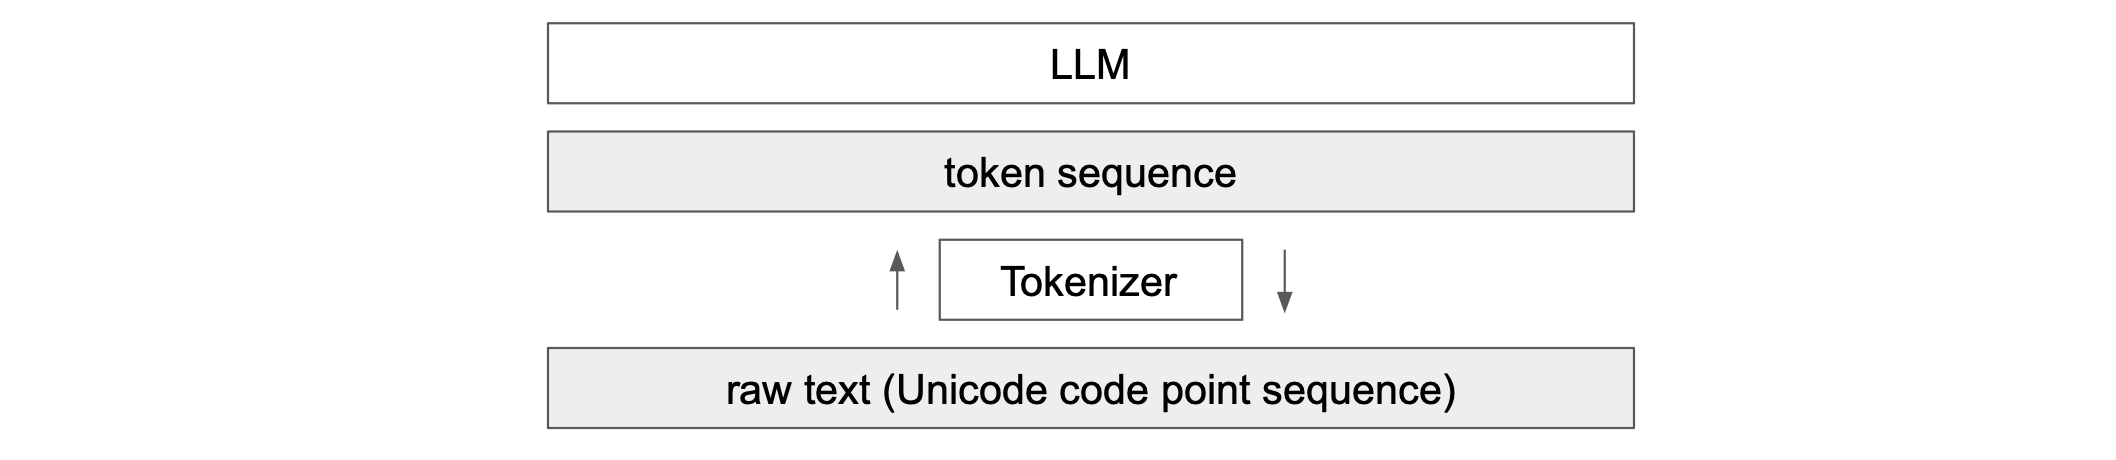

### decoding

Given a sequence of integers in the range [0, vocab_size], what is the text?


## Understanding BPE: bytes, token ids, merges, and vocab

**Raw bytes**: numbers from 0–255, each representing one original byte (character).
Example: `97` = 'a', `98` = 'b'

**Token id**: a new number assigned after merging two tokens. It's just a counter
(256, 257, 258, ...) — it has **no math relation** to the numbers it came from.

**`merges` dict**: maps a pair of adjacent tokens → the new id that replaces them.
```python
merges = {(97, 98): 256}
```
Meaning: "whenever 97 is followed by 98, replace both with 256."

**`vocab` dict**: maps a token id → the actual bytes it represents.
```python
vocab[256] = vocab[97] + vocab[98]  # b'a' + b'b' = b'ab'
```
This `+` is **concatenation** (joining bytes), not addition. So `256` does NOT
mean `97 + 98` numerically — it's just a new label, while the *real* meaning
lives in `vocab` as the joined byte sequence.

### Example walkthrough
Start: `ids = [97, 98, 97, 98, 99, 97, 98]` (a b a b c a b)

**Step 1** — most frequent pair is `(97, 98)` → new id `256`



**Step 2** — most frequent pair is `(256, 256)` → new id `257`


### Summary table

| Concept | What it really is |
|---|---|
| Raw byte | 0–255, one original character |
| Token id (256+) | just a counter, no math meaning |
| `merges` | pair → new id (which pair becomes which id) |
| `vocab` | id → actual bytes (grows by concatenation, not addition) |


In [ ]:
def decode(ids):
  token = b"".join(vocab[idx] for idx in ids)
  text = token.decode("utf-8" , errors="replace")
  return text


# Encodes input text into token IDs using pre-trained merge rules.

    pair = min(stats, key=lambda p: merges.get(p, float("inf")))


"It doesn't select the pair with the highest frequency; it selects the pair with the lowest rank/index in merges."

In [ ]:
tokens= list(text.encode('utf-8'))

In [ ]:
def encode(text):
  # given a string, return list of integers (the tokens)
  tokens = list(text.encode("utf-8"))
  while len(tokens) > 1:
    stats = get_stats(tokens)
    pair = min(stats, key=lambda p: merges.get(p, float("inf")))
    if pair not in merges:
      break # nothing else can be merged
    idx = merges[pair]
    tokens = merge(tokens, pair, idx)
  return tokens
ids=encode(text)
print(ids)
print(len(ids))
print(decode(ids))


[65, 32, 80, 326, 103, 114, 324, 109, 260, 369, 73, 110, 116, 326, 100, 117, 99, 315, 32, 288, 327, 77, 268, 371, 51, 264, 50, 48, 49, 55, 32, 194, 183, 32, 67, 111, 100, 284, 194, 183, 32, 50, 50, 32, 67, 357, 109, 269, 318, 32, 239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 263, 189, 32, 240, 159, 135, 186, 263, 140, 240, 159, 135, 179, 263, 140, 240, 159, 135, 174, 263, 140, 240, 159, 135, 168, 263, 140, 240, 159, 135, 180, 263, 140, 240, 159, 135, 169, 263, 140, 240, 159, 135, 170, 33, 32, 240, 159, 152, 132, 32, 336, 256, 358, 272, 110, 324, 256, 292, 321, 107, 297, 102, 101, 268, 32, 301, 97, 119, 256, 257, 288, 275, 104, 101, 268, 318, 285, 112, 326, 103, 114, 324, 109, 260, 258, 119, 266, 108, 100, 342, 388, 273, 87, 256, 308, 32, 107, 110, 317, 32, 119, 256, 293, 392, 262, 2

In [ ]:
print(decode(encode("hello world")))

hello world


In [ ]:
text2 = decode(encode(text))
text2 == text

True

In [ ]:
valtext = "Many common characters, including numerals, punctuation, and other symbols, are unified within the standard and are not treated as specific to any given writing system. Unicode encodes thousands of emoji, with the continued development thereof conducted by the Consortium as a part of the standard.[4] Moreover, the widespread adoption of Unicode was in large part responsible for the initial popularization of emoji outside of Japan. Unicode is ultimately capable of encoding more than 1.1 million characters."
valtext2 = decode(encode(valtext))
print(valtext2 == valtext)

True


In [ ]:
import regex as re
gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")

print(re.findall(gpt2pat, "Hello've world123 how's are you!!!?"))

['Hello', "'ve", ' world', '123', ' how', "'s", ' are', ' you', '!!!?']


In [ ]:
import json , os

# 2. Load encoder.json
encoder_path = '/content/drive/MyDrive/Data LLM/encoder.json'
with open(encoder_path, 'r', encoding='utf-8') as f:
    encoder = json.load(f)  # <--- ~equivalent to our "vocab"

# 3. Load vocab.bpe and build merges list
bpe_path = '/content/drive/MyDrive/Data LLM/vocab.bpe'
with open(bpe_path, 'r', encoding='utf-8') as f:
    bpe_data = f.read()


In [ ]:
bpe_merges=[tuple(merge_str.split()) for merge_str in bpe_data.split('\n')[1:-1]]
# ^---- ~equivalent to our "merges"

In [ ]:
encoder

{'!': 0,
 '"': 1,
 '#': 2,
 '$': 3,
 '%': 4,
 '&': 5,
 "'": 6,
 '(': 7,
 ')': 8,
 '*': 9,
 '+': 10,
 ',': 11,
 '-': 12,
 '.': 13,
 '/': 14,
 '0': 15,
 '1': 16,
 '2': 17,
 '3': 18,
 '4': 19,
 '5': 20,
 '6': 21,
 '7': 22,
 '8': 23,
 '9': 24,
 ':': 25,
 ';': 26,
 '<': 27,
 '=': 28,
 '>': 29,
 '?': 30,
 '@': 31,
 'A': 32,
 'B': 33,
 'C': 34,
 'D': 35,
 'E': 36,
 'F': 37,
 'G': 38,
 'H': 39,
 'I': 40,
 'J': 41,
 'K': 42,
 'L': 43,
 'M': 44,
 'N': 45,
 'O': 46,
 'P': 47,
 'Q': 48,
 'R': 49,
 'S': 50,
 'T': 51,
 'U': 52,
 'V': 53,
 'W': 54,
 'X': 55,
 'Y': 56,
 'Z': 57,
 '[': 58,
 '\\': 59,
 ']': 60,
 '^': 61,
 '_': 62,
 '`': 63,
 'a': 64,
 'b': 65,
 'c': 66,
 'd': 67,
 'e': 68,
 'f': 69,
 'g': 70,
 'h': 71,
 'i': 72,
 'j': 73,
 'k': 74,
 'l': 75,
 'm': 76,
 'n': 77,
 'o': 78,
 'p': 79,
 'q': 80,
 'r': 81,
 's': 82,
 't': 83,
 'u': 84,
 'v': 85,
 'w': 86,
 'x': 87,
 'y': 88,
 'z': 89,
 '{': 90,
 '|': 91,
 '}': 92,
 '~': 93,
 '¡': 94,
 '¢': 95,
 '£': 96,
 '¤': 97,
 '¥': 98,
 '¦': 99,
 '§': 100

In [ ]:
print(len(bpe_merges))

In [ ]:
bpe_merges

In [ ]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base") # GPT-4 tokenizer
print(enc.encode("안녕하세요 👋 (hello in Korean!)"))
print(enc.decode(enc.encode("안녕하세요 👋 (hello in Korean!)")) == "안녕하세요 👋 (hello in Korean!)")
# match the above for your own tokenizer, and also implement a train() function

[31495, 230, 75265, 243, 92245, 62904, 233, 320, 15339, 304, 16526, 16715]
True


### sentencepiece

Commonly used because (unlike tiktoken) it can efficiently both train and inference BPE tokenizers. It is used in both Llama and Mistral series.

[sentencepiece on Github link](https://github.com/google/sentencepiece).

**The big difference**: sentencepiece runs BPE on the Unicode code points directly! It then has an option `character_coverage` for what to do with very very rare codepoints that appear very few times, and it either maps them onto an UNK token, or if `byte_fallback` is turned on, it encodes them with utf-8 and then encodes the raw bytes instead.

TLDR:

- tiktoken encodes to utf-8 and then BPEs bytes
- sentencepiece BPEs the code points and optionally falls back to utf-8 bytes for rare code points (rarity is determined by character_coverage hyperparameter), which then get translated to byte tokens.

(Personally I think the tiktoken way is a lot cleaner...)

In [ ]:
import sentencepiece as spm

` encoding="utf-8" `

دي معناها

لما
Python

 يتعامل مع النص الموجود في الملف،
  
  استخدم

 ` UTF-8 `

 كطريقة لترميز وفك ترميز النص.

يعني:

 ` Python String `

     ↓
  ` UTF-8 `

     ↓
 `  Bytes`

     ↓

   ` File `


`وعند القراءة

`File`

 ↓

`Bytes`

 ↓

` UTF-8`

 ↓

`Python String`

In [ ]:
# write a toy.txt file with some random text
with open("toy.txt", "w", encoding="utf-8") as f:
  f.write("SentencePiece is an unsupervised text tokenizer and detokenizer mainly for Neural Network-based text generation systems where the vocabulary size is predetermined prior to the neural model training. SentencePiece implements subword units (e.g., byte-pair-encoding (BPE) [Sennrich et al.]) and unigram language model [Kudo.]) with the extension of direct training from raw sentences. SentencePiece allows us to make a purely end-to-end system that does not depend on language-specific pre/postprocessing.")



In [ ]:
"""text_content = أسلم عُمر بن الخطاب -رضي الله عنه- في السنة السادسة من البعثة، وكان عُمره سبعةً وعشرين سنة، وقد كان إسلامهُ بدايةً لمرحلةٍ جديدةٍ من مراحل الدعوة. وقال عبد الله بن مسعود -رضي الله عنه- عن إسلامه: «ما زلنا أعزّة منذ أسلم عُمر»، وكان السببُ في إسلامه دعوةُ النبيّ -عليه الصلاةُ والسلام- بأن يُعَزّ الإسلام بأحبِّ الرجُلين إلى الله -عزّ وجل-؛ عمر بن الخطاب أو أبو جهل، فكان عُمر -رضي الله عنه-.

وأمّا بالنسبةِ لِهجرتهِ فقد كان الوحيد الذي هاجر علناً بعد أن أخذ سيفه وقوسه وسِهامه، ثمَّ ذهب إلى الكعبة، وطاف بها سبعاً، وصلّى ركعتين عند المقام، ثُمّ قال للمُشركين: شاهت الوجوه، وهدَّدهم إن تَبِعوه، وقال مقولته الشهيرة: «ها أنا أخرج إلى الهجرة، فمن أراد لقائي، فليلقني في بطن هذا الوادي»، فلم يستطع أحدٌ أن يمنعه ويتبعه.[١]

وقد هيّأَ الله -تعالى- لهُ أسباب الهداية، فكان ذات يوم جالساً عند الكعبة والقوم يتشاورون فيمن يقتل محمداً الذي فرّق جمعهم، فتوشّح بسيفه، وذهب لِيجدَ محمداً، فذكروا له أنّه عند جبل الصفا في دار الأرقم، فلَقيهُ رَجُلٌ وأخبرهُ بإسلامِ أُختهِ وزوجِها، فغضب لهذا الأمر، ومضى إليهما وكانا يقرآن القُرآن، فلمّا دخل عليهما سألهما إن كانا قد أسلما، وضرب زوجها، وجلس على صدره، فجاءت تدفعه عنه، فضربها على وجهها، فأخبرته بإسلامها مع زوجها، فرقّ قلبه بعد، وأراد أن يقرأ في الصحيفة، فرفضت أُخته حتى يتطهّر، فتطهّر وقرأ منها بداياتِ سورةِ طه، فنزل القُرآن في قلبه، وطلب منهم أن يدلّوه على النبيّ -صلى الله عليه وسلم-.

فلمّا وصل سأل عمر -رضي الله عنه- عن مكان النبيّ -عليه الصلاةُ والسلام- ليُعلن إسلامه، فجاء إليه وضرب الباب، فلم يتجرأ أحدٌ من الصحابة الكرام فتح الباب له، لِما علموا من قوّته وبطشه.[٢] فقام إليه حمزة -رضي الله عنه- وأدخله إلى النبيّ -عليه الصلاةُ والسلام-، وسأله عن سبب مجيئه، فشهد أن لا إله إلا الله وأنّ محمداً رسول الله، فكبّر النبي -صلى الله عليه وسلم- والصحابة -رضوان الله عليهم- فرحاً بهذا الخبر.

ثُمّ بدأ بالدعوة بكلِّ ما أوتِيَ من قوّة، وكان حريصاً على إظهار وإشهار إسلامه، فذهب وصلّى عند الكعبة ومعه جمعٌ من المُسلمين، ثُمّ أُشيع خبرُ إسلامهِ بين المُشركين، فلم يجرؤ أحدٌ منهم بالرّدِّ عليه، فكان لإسلامهِ الأثر الكبير في عِزَّة الإسلامِ والمُسلمين، وكان إسلامهُ بعد إسلام حمزة -رضي الله عنه- بثلاثةِ أيام، حيث كان عددُ المُسلمين تِسعةً وثلاثين، فقال عن نفسه أربعين. وأمّا هِجرتُهُ فكانت علناً، وقدِم المدينة قَبل النبيّ -عليه الصلاةُ والسلام-، ولَحقهُ عددٌ من الصحابة الكرام بلغ عددهم قُرابة العشرين، وبقي يُدافعُ عن الإسلام وأهله، ولا يخشى أحداً.[٢][٣]

قصة جهاد عمر مع النبيّ
أجمعُ العُلماء على مُشاركة عُمر -رضي الله عنه- في جميع الغزوات والمعارك مع النبيّ -عليه الصلاة والسلام-، ولم يتخلّف عن أيٍّ منها، فقد شارك في غزوة بدر، وشاورهُ النبيّ -عليه الصلاةُ والسلام- في قتال المُشركين، فتكلّم وأحسن، ودعا إلى قتالهم. كما كان له الأثر الكبير في إسلامِ العباس عندما وجده بين الأسرى، وقال له إنّ إسلامَ عمِّ النبيّ -عليه الصلاةُ والسلام- أحبُّ إليه من إسلام الخطاب، لِشدّة حبّه للنبي. ولمّا جاء عُميرُ بن وهب لِرؤية أخيه في الأسرى، أخذها حُجّةً لِقتل النبيّ -عليه الصلاةُ والسلام-، فحذّر عُمر -رضي الله عنه- الصحابة الكرام منه وذلك لفراسته، وكان صادقاً في ذلك، فحموا النبيّ ووضع عمر أشخاصاً لحراسته.[٤]

أمّا في غزوةِ أُحد فكان موقفهُ واضحاً وجريئاً في الردِّ على أبي سُفيان. وفي غزوة بني المصطلق لمّا وصل إليه قول عبد الله بن أبيّ بن سلول رأس المنافقين بوصفه للنبيّ -عليه الصلاةُ والسلام- بالذليل، أستأذن النبيّ -عليه الصلاةُ والسلام- في قتلهِ. أمّا في غزوة الخندق، فقد سَبَّ قُريشاً لأنّها ألْهَتهم عن أداء صلاة العصر، وفي صُلح الحُديبية كان أوّلَ من دَعاهُ النبيّ -عليه الصلاةُ والسلام- للذهاب إلى قُريش ومُشاورتهم، وقد أبدى المعارضة على الصُلح في البداية لِما فيه من إجحافٍ بالمُسلمين في ظاهره، ثم شرح الله صدره للصلح وعرف الحِكمة من ذلك.[٤]

وفي السنة السابعة من الهِجرة بعثهُ النبيّ -عليه الصلاةُ والسلام- ومعه ثلاثون رَجُلاً لمحاربة هوازن، فلمّا أتى هوازن الخبر هربوا، ولم يَلقَ عمر ومن معه أحداً منهم، مما يُؤكد على ثقة النبيّ -عليه الصلاةُ والسلام- به، وقُدرتهِ -رضي الله عنه- على القيادة. وأمّا موقفه في غزوة خيبر فقد أعطاه النبيّ -عليه الصلاةُ والسلام- اللّواء في البداية، وفي فتح مكة جاءت قُريش بأبي سفيان ليشفع لهم عند النبيّ -عليه الصلاةُ والسلام-، فردَّ عليه عمر -رضي الله عنه-: «والله، لو لم أجد إلا الذّر لجاهدتكم به». أمّا في غزوة حُنين فقد كان ممن ثبت مع النبيّ -عليه الصلاةُ والسلام- بعد ذهاب الناس عنه، وفي غزوةِ تبوك تبرّع بنصف ماله، ودعا له النبيّ -عليه الصلاةُ والسلام- بالبركة.[٤]

قصص عمر في خلافة أبي بكر الصدّيق
عَرَفَ عُمر بن الخطاب -رضي الله عنه- الفضل الكبير لأبي بكرٍ -رضي الله عنه-، فكان يرضى بِحُكمهِ، ولم يرضَ أن يكون خليفةً وأبو بكر -رضي الله عنه- موجود. وقد كان سبباً في إيقاف الفتنة والفُرقة بين المُسلمين، فبعد وفاة النبيّ -عليه الصلاةُ والسلام- واجتماعهم في سقيفة بني ساعدة، بايع أبا بكرٍ -رضي الله عنه-، وتابعه الصحابة الكرام في مُبايعته، وذكّر الأنصار بفضائل أبي بكر -رضي الله عنه-؛ كأَمْر النبيّ -عليه الصلاةُ والسلام- له بالصلاة في الناس وهو في مرضه. كما عارضَ عمرٌ أبا بكر -رضي الله عنهما- في قتال المُرتدين ومانعي الزكاة في بداية الأمر، ولكنّ أبا بكرٍ -رضي الله عنه- بقيَ مُصرّاً على قتالهم؛ لتفريقهم بين أركان الإسلام، فشرح الله -تعالى- قلب عُمر -رضي الله عنه- لِلأخذ برأي أبي بكر.[٥]

ومن مواقفه في معركة اليمامة والتي أدت إلى استشهاد عددٍ كبيرٍ من قُرّاء الصحابة الكِرام؛ فخشي عُمر -رضي الله عنه- من ضياع القُرآن بِموتهم، فأشار على أبي بكر -رضي الله عنه- بجمع القُرآن، حتى شرح الله -تعالى- قلب أبي بكرٍ -رضي الله عنه- لجمع القرآن.[٥] ومن مواقفه -رضي الله عنه- أيضاً؛ رأيُه في عدم قبول ديّة قتلى المُسلمين في حُروب الردّة، واعتراضه على اقتطاع أرضٍ من أموال المُسلمين للأقرع بن حابس وعُيينه بن حصن، لاشتراكِ جميع المُسلمين فيها، وذلك بعد أن طلب أبو بكرٍ -رضي الله عنه- منهم الذهاب إلى عُمر -رضي الله عنه- وأخذ رأيه في إقطاعهم. كما كان عُمر مُعاوناً ومُستشاراً لأبي بكر -رضي الله عنه-، ويُساعدهُ في إدارة الرعيّة، واستخلفه أبو بكر على المدينة عند خُروجه، وصلّى بالناس في غيابه، كما كان يقوم بشؤون الرعيّة، وتولّى القضاء في زمن ابي بكر -رضي الله عنه-.[٦]

قصص عمر مع رعيته
طبّق عُمر -رضي الله عنه- منهج القُرآن وسُنّة النبيّ -عليه الصلاةُ والسلام- في تعامله مع رعيّته، فقد كان يَهتمّ بنساء المُجتمع وبناته، ويرعى شؤونهنّ في حال غياب أزواجهنّ في الجهاد، ويقومُ على الأرامل، ويتفقّد أحوال المُجتمع في الليل، ويحرص على قضاء حاجاتهم، ويَهتمُ بصحّتهم. وكان يَنهى من به مرضٌ مُعدٍّ أن يخالطَ الناس، وينصحه بالمكوث في بيته. وكان يأمر بما فيه مصلحة الرعيّة، مما أكسبهُ المهابة في نفوسهم وقُلوبهم، فقد جاء عن ابن عباس -رضي الله عنه- أنّه مكث سنةً وهو يُريد سؤاله عن معنى آيةٍ من القُرآن، فلم يستطع من كثرة مهابته.[٧] كما كان عمر -رضي الله عنه- يهتمّ بأُمور الفُقراءِ والمساكين، ويَحملُ لهم الطعام على ظهره، وتَبِعَهُ طلحة -رضي الله عنه- في الليل فوجدهُ يدخل على بيتِ عجوزٍ عمياء مُقعدة، ويقوم على خدمتها ورعايتها، ويهتمُ بشؤونها.[٨]

قصة عمر بن الخطاب في عام الرمادة
جاء أحدُ الرعية لِعُمر -رضي الله عنه- في عام الرمادة بِخُبزٍ مفتوتٍ بِسَمنٍ، فأكل منه، وكان معه رَجُلٌ من البادية، فسأله عن أكلهم، فأخبره أنّه لم يذق السمن منذ كذا وكذا، فأقسم عمر أن لا يأكل اللّحم والسّمن حتى يحيا الناس. وكان لا يأكل حتى تغيّر لونه؛ لِشدّة ما وصل به الجوع، كما أنّه كان يُكثر من الصيام، وجِيء إليه بلحم إبلٍ فلم يأكل منها، فقال: «بئس الوالي أنا، إن أكلت طَيّبها، وأُطعِم الناس عظمها» لِما كان عنده من الشعور بالمسؤولية العظيمة أمام الله -تعالى-.[٩]

وقد قام ببناء مُعسكراتٍ للّاجئين في عام الرمادة، ووزّع المهام بين عُمّاله، ورُويَ عنه كثرة قيامه للّيل، ودعاء الله -تعالى- برفع الوباء والبلاء عن المُسلمين، وأن لا يكون هلاك الأمّة في زمنه. وكان -رضي الله عنه- يُطعم الناس، ويُرسلُ إليهم الطعام إلى بيوتهم، وقام بكتابة الرسائل إلى عُمّاله في الأمصار يطلبُ منهم العون والمُساعدة، فبعث إليه عمرو بن العاص -رضي الله عنه- بألف بعيرٍ مُحمّلةٍ بالدقيق، وعشرين سفينةً مُحمّلةً بالدقيق والدُهن، وغير ذلك من المساعدات من عُماله في الأمصار المُختلفة، فقام -رضي الله عنه- بتوزيعها على الرعيّة من خلالِ لِجانٍ مُختصّة.[٩]

ويُعرف عام الرمادة بأنّه العام الذي أُصيب الناس فيه بمجاعةٍ شديدة، وجدبٍ في الأرض، وكان ذلك في السنة الثامنة عشرة للهجرة، فكان الرجل يذبح الشاة ليأكلها فيعافُها من قُبحها وهزلها، ومات الكثير من المواشي من شدّة الجوع. وسُمّيَ بذلك الاسم لأنّ الريح كانت تحمل التراب كالرماد، واستمَّر ذلك تسعةَ أشهرٍ حتى خرج عُمر مع العباس -رضي الله عنهما- عمّ النبي واستسقيا، فسقاهُما الله -تعالى-. كما قام بأداء صلاة الاستسقاء، والاستعانة بالله -تعالى- ودُعائه، وطلب من الناس الإكثار من الاستغفار. كما أوقف حدِّ السرقة في ذلك العام، وأوقف إلزامه للناس بدفع الزكاة في ذلك العام، وجعلها دَيْناً في أعناقهم عند خُصوبة أراضيهم.[١٠]

قصة عمر بن الخطاب مع طاعون عمواس
وقع في العام الثامن عشر من الهجرة طاعوناً سُمّيَ بطاعون عمواس، نسبةً إلى بلدة عمواس الواقعةِ بين القُدس والرملة، وكانت أوّل مكانٍ يظهر الطاعون بها، ثُمّ انتشر في بقيّة الشام. وهو مرضٌ ينشأ عن تهيجٍ في الدم ينصبّ في العضو ويفسده، وكان وقوعه بعد حربٍ بين المُسلمين والروم، وكثرة القتلى، وتعفّن الجوُّ وفساده من الجُثث. وقد أراد عُمر في السنة السابعة عشر للهجرة الذهاب إلى الشام، فأخبره أحدهم بوقوع الطاعون بها، فرجع إلى المدينة عملاً بالحجر الصحي النبوي.[١١]

فكتب إلى أبي عُبيدة -رضي الله عنه- بالخروج لِينجوا قبل إصابته بالطاعون، فرفض ذلك لمخالطته للناس، وبقيَ حتى مات بالطاعون، فبكى عُمر بن الخطاب -رضي الله عنه- وحزن على فراقه وفراق قادة المسلمين، حيث مات كثيرٌ من الصحابة الكرام بالطاعون ممن كانوا بالشام. واقترح عمر بن الخطاب -رضي الله عنه- على الناس التفرّق في الجبال، ليرفعه الله -تعالى- عنهم، ونفّذَ ذلك عمرو بن العاص -رضي الله عنه- بعد وفاة القادة هناك. وبدأ عمر بن الخطاب -رضي الله عنه- بتقسيم مواريث أهل الشام الذين ماتوا بالطاعون، وولّى الولاة على الأمصار، ورتّب أمور الجُند والقادة والناس.[١١]

قصة عمر مع الحطيئة والزبرقان
خرج الحُطيئة بأهله إلى العراق فراراً من الجوع، وطلباً للعيش، فلقيه الزبرقان، وهو عامل عُمر -رضي الله عنه- في جمع الزكاة، فطلب منه أن ينتظره حتى يرجع. ثُمّ لقيَه بغيض بن عامر بن شماس الذي كان عدواً للزبرقان، فحرّضه علي الزبرقان، فاستجاب له، فقام الحطيئة بهجاء الزبرقان، فرفعهُ إلى عُمر -رضي الله عنه-. وقام باستدعاء حسان -رضي الله عنه- في بيان معنى أبيات الشعر التي قالها الحُطيئة، فبيّن أنّها نوعٌ من الهِجاء، فسجنهُ عُمر -رضي الله عنه-. ثُمّ قام الحُطيئة باستعطاف عُمر -رضي الله عنه- بأبياتٍ من الشعر، فلم يردّ عليه، ثُمّ كتب له بأبياتٍ أُخرى يستعطفهُ بها، فرقّ له وأمر بإطلاقِ سراحه، ونهاهُ عن الهِجاء، وورد أنّه توقف عن الهِجاء في زمنه.[١٢]

with open("story.txt", "w", encoding="utf-8") as f:
    f.write(text_content)
"""

## SentencePiece Training Parameters

### `normalization_rule_name="identity"`

كلمة **`identity`** تعني: **اترك النص كما هو بالضبط**.

نماذج الذكاء الاصطناعي الحديثة (LLMs) تكره تنظيف النص المسبق وتفضل رؤية النص بحالته الأصلية.

---

### `remove_extra_whitespaces=False`

يمنع المكتبة من حذف المسافات المتكررة، لأن المسافات المتعددة مهمة جداً خصوصاً في الأكواد البرمجية كمسافات الإزاحة **Indentation**.

---

### `input_sentence_size`

الحد الأقصى لعدد الجمل التي سيقرأها من الملف (رقم ضخم لضمان قراءة الملفات الكبيرة).

---

### `max_sentence_length`

أقصى طول للجملة الواحدة بالبايتات **(4192 بايت)**.

---

### `seed_sentencepiece_size`

عدد الرموز الأولية التي يتم الاحتفاظ بها في الذاكرة قبل بدء الدمج والتصفية.

---

### `shuffle_input_sentence=True`

خلط الجمل عشوائياً قبل التدريب لتحسين جودة التوزيع وتجنب التحيز.

---

### `character_coverage`

يطلب من الموديل تغطية **99.995%** من الحروف الموجودة في النص، وتجاهل الحروف النادرة جداً (الشاذة) لتوفير مساحة القاموس.

---

### `byte_fallback=True`

**أهم سطر!**

إذا واجه الموديل حرفاً نادراً جداً لم يتدرب عليه (تم استبعاده)، لا تقم بتحويله إلى `<unk>` المجهول، بل حوله إلى بايتات **(UTF-8 Bytes)** حتى لا يفقد الموديل البيانات.

---

### `split_digits=True`

يفصل الأرقام الفردية.

مثلاً:

`123`

لا تندمج كتوكن واحد، بل كأرقام منفصلة:

`1` و `2` و `3`

مما يجعل الموديل أقوى في العمليات الحسابية.

---

### `split_by_unicode_script`

يمنع دمج حروف من لغات مختلفة.

مثلاً: يمنع دمج حرف عربي مع إنجليزي في توكن واحد.

---

### `split_by_whitespace` & `split_by_number`

يفصل عند المسافات وعند تغير نوع البيانات:

**حروف ثم أرقام.**

---

### `add_dummy_prefix=True`

يضيف **"مسافة وهمية"** في بداية كل نص، حتى يتم اعتبار الكلمة الأولى في الجملة كأنها في المنتصف ومسبوقة بمسافة.

وهذا يمنع تكرار الكلمات في القاموس.

---

### `allow_whitespace_only_pieces`

يسمح للموديل بعمل توكنز مكونة من مسافات بيضاء فقط.

مفيد جداً في كتابة الأكواد.

---

## Special Token IDs

تحديد الأرقام المرجعية **(IDs)** للرموز الخاصة في القاموس:

### `unk_id=0`

رمز المجهول **Unknown** (إجباري في SentencePiece).

---

### `bos_id=1`

رمز بداية الجملة **Begin Of Sentence** (`<s>`).

---

### `eos_id=2`

رمز نهاية الجملة **End Of Sentence** (`</s>`).

---

### `pad_id=-1`

رمز الحشو **Padding**.

ووضع القيمة `-1` يعني إيقاف تفعيله (لا يوجد رمز حشو).

In [ ]:
import sentencepiece as spm

In [ ]:
# train a sentencepiece model on it
# the settings here are (best effort) those used for training Llama 2
import os

options = dict(
  # input spec
  input="toy.txt",
  input_format="text",
  # output spec
  model_prefix="tok400", # output filename prefix
  # algorithm spec
  # BPE alg
  model_type="bpe",
  vocab_size=400,
  # normalization

  normalization_rule_name="identity", # ew, turn off normalization

  remove_extra_whitespaces=False,

  input_sentence_size=200000000, # max number of training sentences
  max_sentence_length=10000, # max number of bytes per sentence
  seed_sentencepiece_size=1000000,
  shuffle_input_sentence=True,
  # rare word treatment

  character_coverage=0.99995,
  byte_fallback=True,

  # merge rules
  split_digits=True,
  split_by_unicode_script=True,
  split_by_whitespace=True,
  split_by_number=True,

  max_sentencepiece_length=16,#max_sentencepiece_length: أطول توكن يمكن تكوينه لا يتجاوز 16 حرفاً.
  add_dummy_prefix=True,
  allow_whitespace_only_pieces=True,

  # special tokens
  unk_id=0, # the UNK token MUST exist
  bos_id=1, # the others are optional, set to -1 to turn off
  eos_id=2,
  pad_id=-1,
  # systems

  num_threads=os.cpu_count(), # use ~all system resources
 )
spm.SentencePieceTrainer.train(**options)

True

In [ ]:
sp = spm.SentencePieceProcessor()
sp.load('tok400.model')
vocab = [[sp.id_to_piece(idx), idx] for idx in range(sp.get_piece_size())]
vocab

[['<unk>', 0],
 ['<s>', 1],
 ['</s>', 2],
 ['<0x00>', 3],
 ['<0x01>', 4],
 ['<0x02>', 5],
 ['<0x03>', 6],
 ['<0x04>', 7],
 ['<0x05>', 8],
 ['<0x06>', 9],
 ['<0x07>', 10],
 ['<0x08>', 11],
 ['<0x09>', 12],
 ['<0x0A>', 13],
 ['<0x0B>', 14],
 ['<0x0C>', 15],
 ['<0x0D>', 16],
 ['<0x0E>', 17],
 ['<0x0F>', 18],
 ['<0x10>', 19],
 ['<0x11>', 20],
 ['<0x12>', 21],
 ['<0x13>', 22],
 ['<0x14>', 23],
 ['<0x15>', 24],
 ['<0x16>', 25],
 ['<0x17>', 26],
 ['<0x18>', 27],
 ['<0x19>', 28],
 ['<0x1A>', 29],
 ['<0x1B>', 30],
 ['<0x1C>', 31],
 ['<0x1D>', 32],
 ['<0x1E>', 33],
 ['<0x1F>', 34],
 ['<0x20>', 35],
 ['<0x21>', 36],
 ['<0x22>', 37],
 ['<0x23>', 38],
 ['<0x24>', 39],
 ['<0x25>', 40],
 ['<0x26>', 41],
 ['<0x27>', 42],
 ['<0x28>', 43],
 ['<0x29>', 44],
 ['<0x2A>', 45],
 ['<0x2B>', 46],
 ['<0x2C>', 47],
 ['<0x2D>', 48],
 ['<0x2E>', 49],
 ['<0x2F>', 50],
 ['<0x30>', 51],
 ['<0x31>', 52],
 ['<0x32>', 53],
 ['<0x33>', 54],
 ['<0x34>', 55],
 ['<0x35>', 56],
 ['<0x36>', 57],
 ['<0x37>', 58],
 ['<0x38>', 5

In [ ]:
ids = sp.encode("hello 안녕하세요")
print(ids)

[362, 378, 361, 372, 358, 362, 239, 152, 139, 238, 136, 152, 240, 152, 155, 239, 135, 187, 239, 157, 151]


In [ ]:
print([sp.id_to_piece(idx) for idx in ids])

['▁', 'h', 'e', 'l', 'l', 'o', '▁', '<0xEC>', '<0x95>', '<0x88>', '<0xEB>', '<0x85>', '<0x95>', '<0xED>', '<0x95>', '<0x98>', '<0xEC>', '<0x84>', '<0xB8>', '<0xEC>', '<0x9A>', '<0x94>']


**Llama 2 tokenizer proto**
If you'd like to export the raw protocol buffer for the `tokenizer.model` released by meta, this is a [helpful issue](https://github.com/google/sentencepiece/issues/121). And this is the result:

```
normalizer_spec {
  name: "identity"
  precompiled_charsmap: ""
  add_dummy_prefix: true
  remove_extra_whitespaces: false
  normalization_rule_tsv: ""
}

trainer_spec {
  input: "/large_experiments/theorem/datasets/MERGED/all.test1.merged"
  model_prefix: "spm_model_32k_200M_charcov099995_allowWSO__v2"
  model_type: BPE
  vocab_size: 32000
  self_test_sample_size: 0
  input_format: "text"
  character_coverage: 0.99995
  input_sentence_size: 200000000
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  num_threads: 80
  num_sub_iterations: 2
  max_sentence_length: 4192
  shuffle_input_sentence: true
  max_sentencepiece_length: 16
  split_by_unicode_script: true
  split_by_whitespace: true
  split_by_number: true
  treat_whitespace_as_suffix: false
  split_digits: true
  allow_whitespace_only_pieces: true
  vocabulary_output_piece_score: true
  hard_vocab_limit: true
  use_all_vocab: false
  byte_fallback: true
  required_chars: ""
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_surface: " \342\201\207 "
  unk_piece: "<unk>"
  bos_piece: "<s>"
  eos_piece: "</s>"
  pad_piece: "<pad>"
  train_extremely_large_corpus: false
  enable_differential_privacy: false
  differential_privacy_noise_level: 0.0
  differential_privacy_clipping_threshold: 0
}
```

#### vocab_size

- Q: what should be vocab size?
- Q: how can I increase vocab size?
- A: let's see. Reminder: [gpt.py](https://github.com/karpathy/ng-video-lecture/blob/master/gpt.py) from before.

### Final recommendations

- Don't brush off tokenization. A lot of footguns and sharp edges here. Security issues. Safety issues.
- Eternal glory to anyone who can delete tokenization as a required step in LLMs.
- In your own application:
  - Maybe you can just re-use the GPT-4 tokens and tiktoken?
  - If you're training a vocab, ok to use BPE with sentencepiece. Careful with the million settings.
  - Switch to minbpe once it is as efficient as sentencepiece :)


### Also worth looking at

- [Huggingface Tokenizer](https://huggingface.co/docs/transformers/main_classes/tokenizer). I didn't cover it in detail in the lecture because the algorithm (to my knowledge) is very similar to sentencepiece, but worth potentially evaluating for use in practice.

# Vocabulary Size in LLMs

## 1. `vocab_size`

هو عدد الـ **Tokens المختلفة** التي يستطيع الـ Tokenizer إنتاجها.

مثلاً:

`vocab_size = 50,000`

يعني عندنا 50,000 Token مختلفة.

---

## 2. أين يظهر `vocab_size` في الـ Transformer؟

يظهر بشكل أساسي في مكانين:

- **Token Embedding**
- **LM Head**

### Token Embedding

الـ Embedding Table شكلها:

`vocab_size × embedding_dim`

كل Token له Vector يتم تدريبه.

كلما زاد `vocab_size` → زاد عدد الـ Rows → زادت الـ Parameters.

### LM Head

الـ LM Head ينتج **Logit لكل Token** يمكن أن يأتي بعد الـ Token الحالي.

لذلك:

`عدد الـ Outputs = vocab_size`

كلما زاد `vocab_size` → زاد عدد الحسابات والـ Parameters.

---

## 3. لماذا لا نجعل `vocab_size` ضخمًا جدًا؟

### المشكلة الأولى: Parameters و Computation

Vocabulary أكبر يعني:

- Embedding أكبر
- LM Head أكبر
- Parameters أكثر
- Computation أكثر

### المشكلة الثانية: Undertraining

لو عندنا Vocabulary ضخمة جدًا، بعض الـ Tokens ستظهر نادرًا في الـ Training Data.

`Token نادر → أمثلة تدريب قليلة → Updates قليلة → Undertrained`

### المشكلة الثالثة: Tokens كبيرة جدًا

Vocabulary أكبر → Tokens أكبر → Sequence أقصر.

هذا جيد لأنه يسمح للموديل بمعالجة نص أكثر.

لكن لو الـ Tokens أصبحت كبيرة جدًا، قد يتم ضغط كمية معلومات كبيرة داخل Token واحد.

`معلومات كثيرة → Token واحد كبير`

وبالتالي قد لا يحصل الـ Transformer على عدد كافٍ من الـ positions لمعالجة التفاصيل.

---

## 4. Vocabulary Size = Trade-off

### Vocabulary صغيرة

`Tokens أكثر → Sequence أطول → Computation أكثر`

لكن الـ Tokens تكون أصغر وأكثر تفصيلاً.

### Vocabulary كبيرة

`Tokens أقل → Sequence أقصر → Computation أقل`

لكن:

- Parameters أكثر
- Tokens نادرة أكثر
- احتمال ضغط معلومات كثيرة داخل Token واحد

لذلك `vocab_size` يعتبر **Empirical Hyperparameter** وليس له رقم مثالي ثابت.

---

## 5. ماذا لو أردنا إضافة Tokens لموديل متدرب؟

يمكن إضافة Tokens جديدة مثل:

`<USER>`

`<ASSISTANT>`

`<TOOL>`

نقوم بـ:

1. **Resize للـ Embedding**
   - إضافة Rows جديدة.
   - تهيئة الـ Parameters الجديدة بقيم صغيرة عشوائية.

2. **Resize للـ LM Head**
   - إضافة Outputs جديدة للـ Tokens الجديدة.

3. يمكن عمل:

`Freeze Base Model`

ثم تدريب الـ Parameters الجديدة فقط.

هذه العملية تعتبر **Minor Model Surgery**.

---

## 6. إضافة Tokens ليست فقط للـ Special Tokens

## Gist Tokens

الفكرة: نضغط **Long Prompt** إلى عدد قليل من الـ **Tokens الجديدة**.

### الطريقة

`Long Prompt`
↓  
`Teacher Model (Frozen)`
↓  
`Target Output`

وفي نفس الوقت:

`Gist Tokens + Question`
↓  
`Student Model (Frozen)`
↓  
`Prediction`

نحسب:

`Loss = Prediction vs Target`

ثم نعمل **Backpropagation للـ Gist Token Embeddings فقط**.

---

### ماذا يتم تدريبه؟

- `Base Model` → ❌ Frozen
- `Model Weights` → ❌ لا تتغير
- `Gist Token Embeddings` → ✅ يتم تدريبها

بعد التدريب:

`Long Prompt`
↓  
`Gist Tokens`

وبدل إرسال الـ Prompt الطويل كل مرة، نرسل الـ Gist Tokens فقط.

### الفكرة الأساسية

الـ Gist Token **لا يحتوي النص نفسه**، وإنما الـ Embedding الخاص به يتعلم تمثيل المعلومات الموجودة في الـ Prompt الطويل.

**Gist Tokens = Prompt Compression باستخدام Learned Token Embeddings.**